In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)

In [2]:
class Option():
    """Class to define an Option. Expiration should be given in days"""
    def __init__(self,strike,expiration,type):
        self.strike = strike
        self.expiration = expiration
        self.type = type

In [3]:
def calculate_black_scholes_price(option,sigma,S,r):
    """ Using the Black Scholes model to calculate the risk-neutral price of an option (specified as call or put)
     K = Option's strike price
     t = Years to option's expiration
     S = Underlying asset's current price
     sigma = Volatility of the market
     r = Risk-free interest rate
     Formulas for the price + the greeks : https://en.wikipedia.org/wiki/Black%E2%80%93Scholes_model#Black%E2%80%93Scholes_formula"""
    K = option.strike
    t = option.expiration / 365
    d1 = (np.log(S/K) + (r + sigma**2 / 2) * t) / (sigma * np.sqrt(t))
    d2 = d1 - sigma * np.sqrt(t)
    call_price = S*norm.cdf(d1) - K * np.exp(-r*t)*norm.cdf(d2)
    put_price = K*np.exp(-r*t) * norm.cdf(-d2) - S*norm.cdf(-d1)

    # Vega and gamma are the same regardless of if the option is a put or call
    vega = S*norm.pdf(d1) * np.sqrt(t)
    gamma = norm.pdf(d1) / (S*sigma*(np.sqrt(t)))
    if option.type == "Call":
        delta = norm.cdf(d1)
        rho = K * t *np.exp(-r*t)*norm.cdf(d2)
        theta = -(S*norm.pdf(d1)*sigma) / (2*np.sqrt(t)) - r*K*np.exp(-r*t)*norm.cdf(d2)
        return [call_price,delta,gamma,theta,vega,rho]
            
    elif option.type == "Put":
        delta = -norm.cdf(-d1)
        rho = - K * t *norm.cdf(-d2)
        theta = - (S*norm.pdf(d1)*sigma) / (2*np.sqrt(t)) + r*K*np.exp(-r*t)*norm.cdf(-d2)
        return [put_price,delta,gamma,theta,vega,rho]

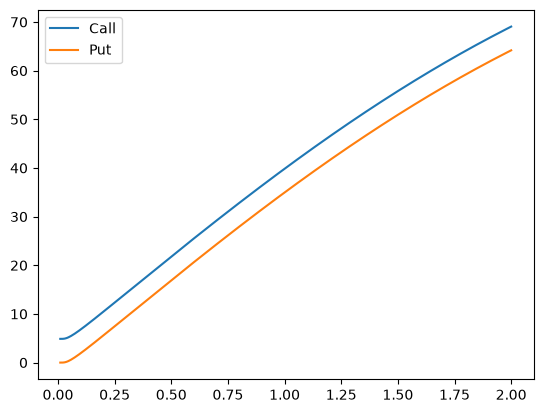

In [9]:
K = 100
call_option = Option(K,365,"Call")
put_option = Option(K,365,"Put")
f = lambda x,y : calculate_black_scholes_price(y,x,100,0.05)[0]
sigmas = np.linspace(0.01, 2, 500)
plt.plot(sigmas,f(sigmas,call_option),label='Call')
plt.plot(sigmas,f(sigmas,put_option),label='Put')
plt.legend(loc="upper left")

# The two graphs are identical, just translated due to the put-call parity
# Since we are holding all variables constant other than volatility, strike price - forward value is constant, so put - call is constant 

In [10]:
def price_path_gbm(S0,mu,sigma,T,dt):
    """Uses a Geometric Brownian Motion model to realise a random path for a stock's price
    s0 = intial stock price
    mu = annual drift / expected rate of return
    sigma = annualised volatility of underlying's returns
    T = no of days to simulation
    dt = no of days distance between each simulated price"""
    predictions = [S0]
    s_t = S0
    dt_in_years = dt/365
    for _ in np.arange(0,T,dt):
        s_t = s_t * np.exp(dt_in_years*(mu - 0.5 * sigma**2) + sigma * rng.normal(scale=np.sqrt(dt_in_years)))
        predictions.append(s_t)
    return predictions


In [11]:
# Per contract (i.e 100 shares)
r  = 0.05
T = 1
price_path = price_path_gbm(100,0.05,0.1,1,1/365)
final_price = price_path[-1]
#plt.plot(np.arange(0,365),price_path)
#plt.plot(np.arange(0,365),[K]*365)
premium = calculate_black_scholes_price(call_option,0.1,100,0.05)[0] * 100
payoff = max(final_price - K,0) * 100
pnl = payoff - premium
print(f"Premium Price : {premium}")
print(f"P/L : {pnl}")

Premium Price : 680.4957708822144
P/L : -680.4957708822144


In [12]:
calculate_black_scholes_price(call_option,0.1,100,0.05)
    

[np.float64(6.804957708822144),
 np.float64(0.7088403132116536),
 np.float64(0.0342943855019384),
 np.float64(-4.918672955714081),
 np.float64(34.29438550193839),
 np.float64(64.07907361234322)]

In [ ]:
# Does Monte Carlo simulation converge to Black scholes?
default_μ  = 0.0001
default_ρ  = 0.1
default_ν  = 0.001
default_S0 = 10
default_h0 = 0
default_n = 10
default_β = 0.95
default_M = 100000

# Calculating option price using Monte Carlo + GBM model
payoffs = np.array([max(price_path_gbm(100,0.05,0.1,365,1)[-1] - K,0) for _ in range(0,default_M)])
price = np.exp(-r*T) * np.mean(payoffs)
print(f"Option Price = {price}")


Option Price = 6.817636798023505
